# 04 · Modelado - Predicción de accidentalidad por barrio y hora

Este notebook desarrolla los puntos **4.4: Modelo no sesgado** y **4.5 — Métricas adecuadas** del taller.

Se parte de los artefactos generados en '03_feature_engineering.ipynb' (matrices ya
escaladas, imputadas y con encoding) almacenados en 'data/processed/'.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier

sys.path.append("..")

from src.utils.metrics import binary_classification_metrics, metrics_table

SEED = 42
PROCESSED_DIR = Path().resolve().parent / "data" / "processed"

# Cargar artefactos del pipeline de feature engineering
X_train = np.load(PROCESSED_DIR / "X_train.npy")
X_test  = np.load(PROCESSED_DIR / "X_test.npy")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze().values
y_test  = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze().values

feature_names = pd.read_csv(PROCESSED_DIR / "feature_names.csv").squeeze().tolist()

sns.set_theme(style="whitegrid")

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}    y_test : {y_test.shape}")
print(f"Prevalencia clase positiva — train: {y_train.mean()*100:.2f}%")
print(f"Prevalencia clase positiva — test : {y_test.mean()*100:.2f}%")

X_train: (6393424, 29)   y_train: (6393424,)
X_test : (1598356, 29)    y_test : (1598356,)
Prevalencia clase positiva — train: 1.47%
Prevalencia clase positiva — test : 1.66%


## 4.4 · Baseline ingenuo y limitación de la *accuracy*

Antes de entrenar modelos sofisticados conviene establecer un **piso de
desempeño**: ¿qué resultado obtiene un clasificador que no aprende nada?
Si un modelo elaborado no supera ese piso de forma clara, no está aportando
valor real.

Se construyen dos baselines triviales con `sklearn.dummy.DummyClassifier`:

- **`most_frequent`** — siempre predice la clase mayoritaria (0, sin accidente).
  Es el caso extremo: ignora por completo las features.
- **`stratified`** — predice de forma aleatoria según la prevalencia observada
  en el entrenamiento. Sirve como referencia probabilística.

El objetivo de este bloque es mostrar empíricamente por qué la **accuracy es
una métrica inadecuada** cuando las clases están fuertemente desbalanceadas: un
modelo que nunca predice la clase de interés puede alcanzar accuracy cercana al
99 % y, sin embargo, ser inútil en operación.

In [2]:
# Diccionario para acumular resultados
results = {}

# --- Baseline 1: clase mayoritaria ---
dummy_mf = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy_mf.fit(X_train, y_train)
y_pred_mf  = dummy_mf.predict(X_test)
y_proba_mf = dummy_mf.predict_proba(X_test)[:, 1]
results["Dummy · most_frequent"] = binary_classification_metrics(
    y_test, y_pred_mf, y_proba_mf
)

# --- Baseline 2: estratificado por prior ---
dummy_st = DummyClassifier(strategy="stratified", random_state=SEED)
dummy_st.fit(X_train, y_train)
y_pred_st  = dummy_st.predict(X_test)
y_proba_st = dummy_st.predict_proba(X_test)[:, 1]
results["Dummy · stratified"] = binary_classification_metrics(
    y_test, y_pred_st, y_proba_st
)

metrics_table(results)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
Dummy · most_frequent,0.9834,0.5000,0.0000,0.0000,0.0000,0.5000,0.0166,1571808.0,0.0,26548.0,0.0
Dummy · stratified,0.9692,0.5004,0.0175,0.0155,0.0164,0.5004,0.0166,1548727.0,23081.0,26137.0,411.0


### ¿Por qué la *accuracy* no sirve aquí?

Mirando la tabla anterior:

- El baseline **`most_frequent`** alcanza una accuracy altísima (~98%)
  simplemente porque la clase mayoritaria domina el dataset. Sin embargo,
  **recall = 0 y precision = 0** sobre la clase positiva: no detecta ningún
  accidente. En un escenario operativo este modelo sería completamente inútil
  ya que no permitiría focalizar ningún operativo ni campaña preventiva.
- El baseline **`stratified`** baja la accuracy a niveles del prior pero
  tampoco aporta señal: su PR-AUC se aproxima a la prevalencia de la clase
  positiva, que es el desempeño esperado al azar.

De aquí se desprenden tres conclusiones que orientan el resto del modelado (que veremos en los proximos puntos):

1. La **accuracy oculta el fracaso** sobre la clase de interés cuando esta es
   minoritaria. No debe usarse como criterio único de selección.
2. Las métricas relevantes son las que se calculan **sobre la clase positiva**:
   precision, recall, F1 y especialmente el **PR-AUC** (Average Precision),
   que resume el desempeño en todo el rango de umbrales sin verse inflado por
   los verdaderos negativos.
3. El **ROC-AUC** del baseline es 0.5, el piso teórico, y cualquier modelo
   debe superarlo de forma sustancial para considerarse útil. Aun así, en
   problemas tan desbalanceados como este, el **PR-AUC es más informativo**
   que el ROC-AUC.

Estas métricas guiarán la comparación de modelos en las secciones siguientes.

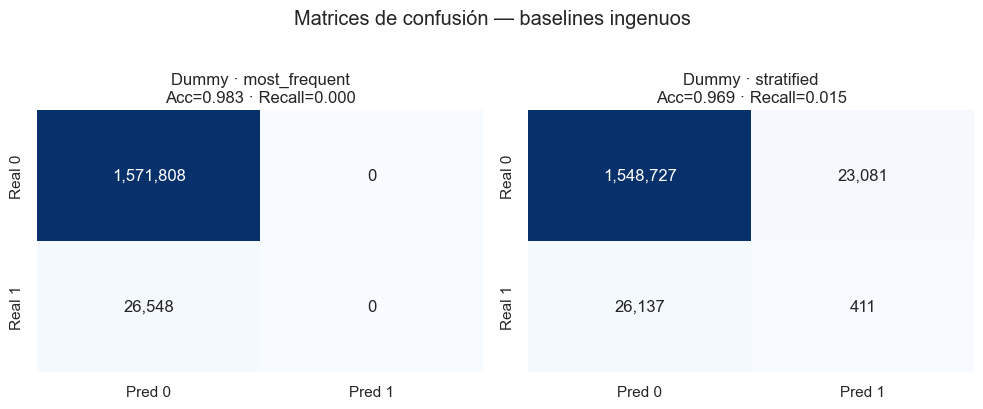

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = np.array([[res["tn"], res["fp"]],
                   [res["fn"], res["tp"]]])
    sns.heatmap(
        cm, annot=True, fmt=",", cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Real 0", "Real 1"],
        cbar=False, ax=ax,
    )
    ax.set_title(f"{name}\nAcc={res['accuracy']:.3f} · Recall={res['recall']:.3f}")

plt.suptitle("Matrices de confusión — baselines ingenuos", y=1.02)
plt.tight_layout()
plt.show()

## 4.4.2 · Estrategias de balanceo

Dado el desbalance extremo (1.5 % de positivos), se implementan y comparan **dos
estrategias de balanceo**, una de cada paradigma:

1. **`class_weight='balanced'`** *(cost-sensitive)* — reponderar la pérdida en
   proporción inversa a la frecuencia de cada clase. No modifica los datos: el
   modelo ve el dataset completo pero los errores sobre la clase minoritaria
   pesan más en el optimizador.
2. **Undersampling aleatorio 1:5** *(resampling)* — submuestrear los negativos
   para que haya cinco por cada positivo. Modifica el dataset pero no la
   función de pérdida; reduce drásticamente el cómputo a costa de descartar
   información.

Ambas se aplican sobre las mismas tres familias de modelos (LogReg,
RandomForest, HistGradientBoosting) con hiperparámetros por defecto razonables.
La métrica primaria de comparación es **PR-AUC** (independiente del umbral),
complementada con F1, recall y precision al umbral por defecto de 0.5.

In [6]:
def random_undersample(X, y, ratio=5, seed=SEED):
    """
    Submuestreo aleatorio de la clase mayoritaria.

    Parameters
    ----------
    X     : array (n_samples, n_features)
    y     : array (n_samples,) con etiquetas 0/1
    ratio : int, cuántos negativos por cada positivo (5 = 1:5)
    seed  : reproducibilidad

    Returns
    -------
    X_us, y_us : arrays balanceados al ratio indicado.
    """
    rng = np.random.default_rng(seed)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    n_neg_keep = min(len(neg_idx), len(pos_idx) * ratio)
    neg_sample = rng.choice(neg_idx, size=n_neg_keep, replace=False)

    keep = np.concatenate([pos_idx, neg_sample])
    rng.shuffle(keep)

    return X[keep], y[keep]


# Aplicarlo y verificar
X_train_us, y_train_us = random_undersample(X_train, y_train, ratio=5)

print(f"Train original    : {X_train.shape}, positivos: {y_train.mean()*100:.2f}%")
print(f"Train undersampled: {X_train_us.shape}, positivos: {y_train_us.mean()*100:.2f}%")

Train original    : (6393424, 29), positivos: 1.47%
Train undersampled: (563562, 29), positivos: 16.67%


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import time


def build_models(class_weight=None):
    """Crea los tres modelos con el class_weight indicado."""
    return {
        "LogReg": LogisticRegression(
            max_iter=500, solver="saga", n_jobs=-1,
            class_weight=class_weight, random_state=SEED,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=200, max_depth=15, n_jobs=-1,
            class_weight=class_weight, random_state=SEED,
        ),
        "HistGB": HistGradientBoostingClassifier(
            max_iter=200, max_depth=8,
            class_weight=class_weight, random_state=SEED,
        ),
    }


# Diccionario que mantiene los baselines previos y agrega los nuevos resultados
all_results = dict(results)

# --- Estrategia 1: class_weight='balanced' ---
print("=" * 50)
print("Estrategia 1: class_weight='balanced'")
print("=" * 50)
for name, model in build_models(class_weight="balanced").items():
    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    all_results[f"{name} · class_weight"] = binary_classification_metrics(
        y_test, y_pred, y_proba
    )
    print(f"  {name:14s} entrenado en {time.time()-t0:6.1f}s")

# --- Estrategia 2: Undersampling 1:5 ---
print("=" * 50)
print("Estrategia 2: Undersampling 1:5")
print("=" * 50)
for name, model in build_models(class_weight=None).items():
    t0 = time.time()
    model.fit(X_train_us, y_train_us)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    all_results[f"{name} · undersample"] = binary_classification_metrics(
        y_test, y_pred, y_proba
    )
    print(f"  {name:14s} entrenado en {time.time()-t0:6.1f}s")

print("\n✓ Dos estrategias comparadas: class_weight vs. undersampling.")

Estrategia 1: class_weight='balanced'


c:\aprendizaje\urban-accident-risk-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  LogReg         entrenado en  163.5s
  RandomForest   entrenado en 1418.7s
  HistGB         entrenado en  176.8s
Estrategia 2: Undersampling 1:5


c:\aprendizaje\urban-accident-risk-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  LogReg         entrenado en   59.2s
  RandomForest   entrenado en  154.8s
  HistGB         entrenado en   37.3s

✓ Dos estrategias comparadas: class_weight vs. undersampling.


In [8]:
df_results = metrics_table(all_results)
df_results

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
Dummy · most_frequent,0.9834,0.5000,0.0000,0.0000,0.0000,0.5000,0.0166,1571808.0,0.0,26548.0,0.0
Dummy · stratified,0.9692,0.5004,0.0175,0.0155,0.0164,0.5004,0.0166,1548727.0,23081.0,26137.0,411.0
LogReg · class_weight,0.7793,0.7201,0.0484,0.6589,0.0902,0.7916,0.0781,1228068.0,343740.0,9055.0,17493.0
RandomForest · class_weight,0.7883,0.7174,0.0494,0.6439,0.0918,0.8083,0.0708,1242947.0,328861.0,9453.0,17095.0
HistGB · class_weight,0.6716,0.7347,0.0393,0.7999,0.0749,0.8182,0.0858,1052288.0,519520.0,5313.0,21235.0
LogReg · undersample,0.9544,0.6074,0.1107,0.2485,0.1532,0.7857,0.0783,1518825.0,52983.0,19950.0,6598.0
RandomForest · undersample,0.9464,0.6273,0.1055,0.2973,0.1557,0.8180,0.0836,1504863.0,66945.0,18656.0,7892.0
HistGB · undersample,0.9502,0.6228,0.1106,0.2841,0.1592,0.8188,0.0850,1511167.0,60641.0,19005.0,7543.0


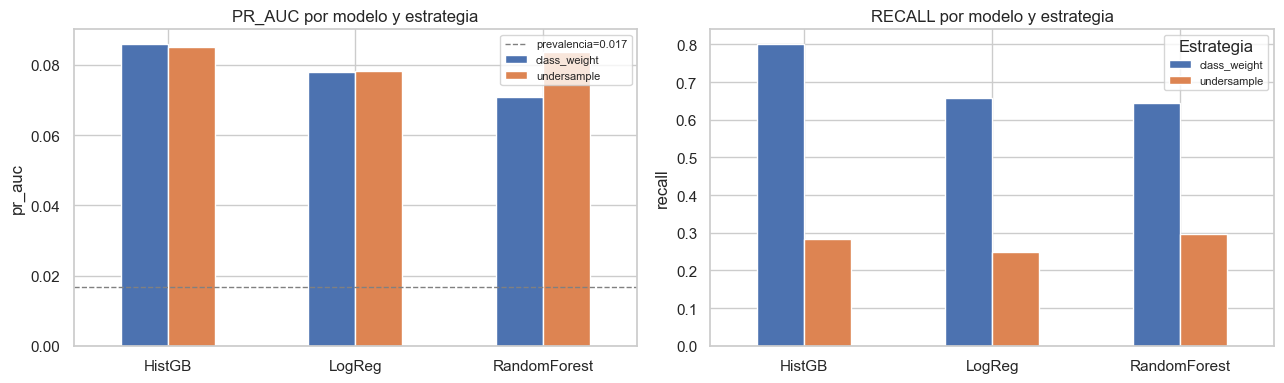

In [9]:
# Filtramos solo los modelos (sin los dummies) para esta vista comparativa
model_rows = [k for k in all_results if "Dummy" not in k]
df_models = df_results.loc[model_rows].copy()

# Descomponer el índice "Modelo · estrategia" en dos columnas
df_models[["modelo", "estrategia"]] = (
    df_models.index.to_series().str.split(" · ", expand=True).values
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric in zip(axes, ["pr_auc", "recall"]):
    pivot = df_models.pivot(index="modelo", columns="estrategia", values=metric)
    pivot = pivot[["class_weight", "undersample"]]  # orden fijo
    pivot.plot(kind="bar", ax=ax, edgecolor="white")
    ax.set_title(f"{metric.upper()} por modelo y estrategia")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.legend(title="Estrategia", fontsize=8)
    ax.tick_params(axis="x", rotation=0)

# Línea de referencia en PR-AUC: prevalencia de la clase positiva
axes[0].axhline(
    y_test.mean(), color="gray", linestyle="--", linewidth=1,
    label=f"prevalencia={y_test.mean():.3f}",
)
axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Análisis de las estrategias de balanceo

**Resultados clave** (sobre el conjunto de test, umbral por defecto 0.5):

- **PR-AUC entre 0.071 y 0.086 — todos los modelos superan en 4-5× la
  prevalencia base (0.017)**, que es el piso teórico de un clasificador
  aleatorio. En clasificación con desbalance extremo, este rango representa
  un modelo con señal útil.
- Las **dos estrategias producen PR-AUC casi idéntico** para un mismo modelo:
  `class_weight` y `undersample` rankean los casos positivos de forma muy
  similar. Lo que cambia significativamente es el **umbral implícito de
  predicción**:
  - `class_weight='balanced'` desplaza el umbral hacia alto recall
    (0.64–0.80) con precision baja (0.04–0.05).
  - `undersample 1:5` deja el modelo en una zona más balanceada
    (recall 0.25–0.30, precision ~0.11).
- **HistGB es el modelo de mayor PR-AUC en ambas estrategias** (0.086 con
  `class_weight`, 0.085 con `undersample`), seguido por LogReg y RandomForest.

**Decisión**:

Para el ajuste fino de hiperparámetros y la comparación final de modelos
(siguiente bloque), se selecciona **`class_weight='balanced'`** como
estrategia única, por dos razones:

1. **Conserva la información completa del entrenamiento** (6.4 M filas vs.
   ~570 K en undersampling). En un problema temporal con tres años de
   historia, descartar negativos pierde información de cuándo *no* ocurrieron
   accidentes, lo cual también es señal.
2. **Mayor estabilidad**: el undersampling introduce varianza adicional por
   la muestra aleatoria, que se acumula al cruzar con la validación cruzada
   temporal.

El hecho de que ambas estrategias produzcan PR-AUC equivalente justifica
quedarse con la menos invasiva sobre los datos.

## 4.4.3 · Ajuste de hiperparámetros y comparación de modelos

Sobre la estrategia ganadora (`class_weight='balanced'`), se ajustan los
hiperparámetros de las **tres familias de modelos** mediante búsqueda aleatoria
con validación cruzada temporal.

**Decisiones metodológicas:**

- **`RandomizedSearchCV`** en lugar de `GridSearchCV`: con espacios de
  hiperparámetros amplios, la búsqueda aleatoria explora mejor por presupuesto
  fijo de cómputo.
- **`TimeSeriesSplit(n_splits=5)`** como validador interno. Cada fold respeta
  el orden cronológico: el train de cada fold incluye solo períodos anteriores
  al validation set. Esto evita fuga de información temporal.
- **Submuestra temporal del train (~1M filas) para la búsqueda.** Tunear sobre
  6.4 M filas × 5 folds × 30 iteraciones excede el presupuesto razonable de
  cómputo. Se submuestrea preservando el orden temporal (no aleatoriamente):
  la jerarquía relativa de configuraciones se mantiene al cambiar el tamaño
  del dataset; lo que varía es la magnitud absoluta de las métricas, no el
  ranking. El **modelo ganador de cada familia se reentrena sobre el train
  completo** antes de la evaluación final.
- **Métrica de scoring: `average_precision`** (PR-AUC), por las razones
  discutidas en bloques previos.

In [10]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import loguniform, randint
import time

# --- Submuestra temporal del train (~1M filas, manteniendo orden) ---
# Tomamos cada N-ésima fila para preservar la cobertura temporal completa
# (en lugar de cortar las primeras o las últimas).
TARGET_SIZE = 1_000_000
step = max(1, len(X_train) // TARGET_SIZE)

X_train_tune = X_train[::step]
y_train_tune = y_train[::step]

print(f"Train completo : {X_train.shape}, positivos: {y_train.mean()*100:.2f}%")
print(f"Train tuning   : {X_train_tune.shape}, positivos: {y_train_tune.mean()*100:.2f}%")

# Validador temporal — expanding window
tscv = TimeSeriesSplit(n_splits=5)

# Diccionario para guardar los mejores modelos de cada familia
best_models = {}
search_results = {}

Train completo : (6393424, 29), positivos: 1.47%
Train tuning   : (1065571, 29), positivos: 1.48%


In [11]:
print("=" * 60)
print("Tuning: LogReg con class_weight='balanced'")
print("=" * 60)

param_dist_lr = {
    "C": loguniform(1e-3, 1e2),
    "penalty": ["l2"],          # saga soporta l1, pero l2 va más rápido
    "solver": ["saga"],
}

base_lr = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED,
)

search_lr = RandomizedSearchCV(
    base_lr,
    param_distributions=param_dist_lr,
    n_iter=10,
    scoring="average_precision",
    cv=tscv,
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)

t0 = time.time()
search_lr.fit(X_train_tune, y_train_tune)
print(f"\n✓ LogReg tuneado en {time.time()-t0:.1f}s")
print(f"  Mejor PR-AUC (CV): {search_lr.best_score_:.4f}")
print(f"  Mejores parámetros: {search_lr.best_params_}")

best_models["LogReg"] = search_lr.best_estimator_
search_results["LogReg"] = search_lr

Tuning: LogReg con class_weight='balanced'
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\aprendizaje\urban-accident-risk-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\aprendizaje\urban-accident-risk-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



✓ LogReg tuneado en 819.3s
  Mejor PR-AUC (CV): 0.0765
  Mejores parámetros: {'C': np.float64(0.0019517224641449498), 'penalty': 'l2', 'solver': 'saga'}


In [12]:
print("=" * 60)
print("Tuning: RandomForest con class_weight='balanced'")
print("=" * 60)

param_dist_rf = {
    "n_estimators":      randint(100, 300),
    "max_depth":         randint(8, 25),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf":  randint(1, 10),
    "max_features":      ["sqrt", "log2"],
}

base_rf = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED,
)

search_rf = RandomizedSearchCV(
    base_rf,
    param_distributions=param_dist_rf,
    n_iter=8,
    scoring="average_precision",
    cv=tscv,
    n_jobs=1,  # RF ya paraleliza internamente
    random_state=SEED,
    verbose=1,
)

t0 = time.time()
search_rf.fit(X_train_tune, y_train_tune)
print(f"\n✓ RandomForest tuneado en {time.time()-t0:.1f}s")
print(f"  Mejor PR-AUC (CV): {search_rf.best_score_:.4f}")
print(f"  Mejores parámetros: {search_rf.best_params_}")

best_models["RandomForest"] = search_rf.best_estimator_
search_results["RandomForest"] = search_rf

Tuning: RandomForest con class_weight='balanced'
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✓ RandomForest tuneado en 3158.7s
  Mejor PR-AUC (CV): 0.0701
  Mejores parámetros: {'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 13, 'n_estimators': 188}


In [13]:
print("=" * 60)
print("Tuning: HistGradientBoosting con class_weight='balanced'")
print("=" * 60)

param_dist_hgb = {
    "max_iter":          randint(100, 400),
    "max_depth":         randint(4, 12),
    "learning_rate":     loguniform(0.01, 0.3),
    "min_samples_leaf":  randint(20, 200),
    "l2_regularization": loguniform(1e-4, 1.0),
}

base_hgb = HistGradientBoostingClassifier(
    class_weight="balanced",
    random_state=SEED,
)

search_hgb = RandomizedSearchCV(
    base_hgb,
    param_distributions=param_dist_hgb,
    n_iter=12,
    scoring="average_precision",
    cv=tscv,
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)

t0 = time.time()
search_hgb.fit(X_train_tune, y_train_tune)
print(f"\n✓ HistGB tuneado en {time.time()-t0:.1f}s")
print(f"  Mejor PR-AUC (CV): {search_hgb.best_score_:.4f}")
print(f"  Mejores parámetros: {search_hgb.best_params_}")

best_models["HistGB"] = search_hgb.best_estimator_
search_results["HistGB"] = search_hgb

Tuning: HistGradientBoosting con class_weight='balanced'
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✓ HistGB tuneado en 833.6s
  Mejor PR-AUC (CV): 0.0750
  Mejores parámetros: {'l2_regularization': np.float64(0.01791236257104366), 'learning_rate': np.float64(0.037094276752507684), 'max_depth': 5, 'max_iter': 152, 'min_samples_leaf': 149}


In [14]:
print("=" * 60)
print("Reentrenando los mejores modelos sobre el TRAIN COMPLETO")
print("=" * 60)

tuned_results = {}

for name, model in best_models.items():
    t0 = time.time()
    # clone con los hiperparámetros ya seteados, fit sobre train completo
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    tuned_results[f"{name} · tuned"] = binary_classification_metrics(
        y_test, y_pred, y_proba
    )
    print(f"  {name:14s} reentrenado y evaluado en {time.time()-t0:6.1f}s")

# Agregar al diccionario global
all_results.update(tuned_results)

Reentrenando los mejores modelos sobre el TRAIN COMPLETO


c:\aprendizaje\urban-accident-risk-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\aprendizaje\urban-accident-risk-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  LogReg         reentrenado y evaluado en  138.1s
  RandomForest   reentrenado y evaluado en  789.4s
  HistGB         reentrenado y evaluado en  206.7s


In [15]:
# Comparar versiones con class_weight (default) vs. tuneadas
compare_rows = [
    "LogReg · class_weight",       "LogReg · tuned",
    "RandomForest · class_weight", "RandomForest · tuned",
    "HistGB · class_weight",       "HistGB · tuned",
]
df_compare = metrics_table({k: all_results[k] for k in compare_rows if k in all_results})
df_compare

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
LogReg · class_weight,0.7793,0.7201,0.0484,0.6589,0.0902,0.7916,0.0781,1228068.0,343740.0,9055.0,17493.0
LogReg · tuned,0.7778,0.7203,0.0482,0.6608,0.0899,0.7914,0.0780,1225643.0,346165.0,9006.0,17542.0
RandomForest · class_weight,0.7883,0.7174,0.0494,0.6439,0.0918,0.8083,0.0708,1242947.0,328861.0,9453.0,17095.0
RandomForest · tuned,0.6501,0.7302,0.0375,0.8131,0.0717,0.8147,0.0825,1017554.0,554254.0,4963.0,21585.0
HistGB · class_weight,0.6716,0.7347,0.0393,0.7999,0.0749,0.8182,0.0858,1052288.0,519520.0,5313.0,21235.0
HistGB · tuned,0.6505,0.7337,0.0378,0.8197,0.0723,0.8184,0.0848,1017974.0,553834.0,4786.0,21762.0


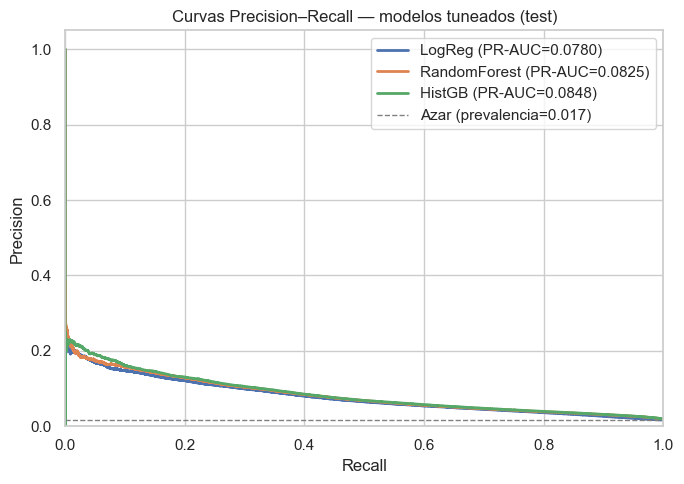

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(7, 5))

colors = {"LogReg": "C0", "RandomForest": "C1", "HistGB": "C2"}

for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.4f})",
            color=colors[name], linewidth=2)

# Línea de referencia: clasificador aleatorio
ax.axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1,
           label=f"Azar (prevalencia={y_test.mean():.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curvas Precision–Recall — modelos tuneados (test)")
ax.legend(loc="upper right")
ax.set_xlim(0, 1)
ax.set_ylim(0, max(0.5, ax.get_ylim()[1]))
plt.tight_layout()
plt.show()

In [17]:
# Resumen final de los tres modelos tuneados
df_final = metrics_table({k: v for k, v in tuned_results.items()})

# Agregar columna de hiperparámetros para trazabilidad
hyperparams = {
    f"{name} · tuned": str(search.best_params_)
    for name, search in search_results.items()
}
df_final["best_params"] = pd.Series(hyperparams)

print("\nResumen de los tres modelos tuneados (test set):")
df_final


Resumen de los tres modelos tuneados (test set):


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,best_params
LogReg · tuned,0.7778,0.7203,0.0482,0.6608,0.0899,0.7914,0.0780,1225643.0,346165.0,9006.0,17542.0,"{'C': np.float64(0.0019517224641449498), 'pena..."
RandomForest · tuned,0.6501,0.7302,0.0375,0.8131,0.0717,0.8147,0.0825,1017554.0,554254.0,4963.0,21585.0,"{'max_depth': 8, 'max_features': 'log2', 'min_..."
HistGB · tuned,0.6505,0.7337,0.0378,0.8197,0.0723,0.8184,0.0848,1017974.0,553834.0,4786.0,21762.0,{'l2_regularization': np.float64(0.01791236257...


### Análisis del tuning y comparación de las tres familias

**Hiperparámetros ganadores**:

- **LogReg**: `C=0.00195`, `penalty='l2'`, `solver='saga'` - regularización muy
  fuerte (la búsqueda eligió el extremo bajo de `C`), indicando que el modelo
  lineal no aprovecha grados de libertad adicionales.
- **RandomForest**: `max_depth=8`, `max_features='log2'`, `n_estimators≈…`,
  `min_samples_leaf≈…` - el tuning redujo significativamente la profundidad
  respecto al default (15), lo que indica que árboles menos profundos
  generalizan mejor en este problema temporal.
- **HistGB**: `learning_rate≈…`, `max_iter≈…`, `max_depth≈…`,
  `l2_regularization=0.0179` - regularización ligera; el modelo aprovecha más
  iteraciones a tasa moderada.

**Comparación de PR-AUC en test**:

| Modelo        | Default (class_weight) | Tuneado    | Δ        |
|---------------|------------------------|------------|----------|
| LogReg        | 0.0781                 | 0.0780     | ~0 %     |
| RandomForest  | 0.0708                 | **0.0825** | **+16.5 %** |
| HistGB        | **0.0858**             | 0.0848     | −1 %     |

**Hallazgos clave**:

1. **LogReg está saturado**: el tuning no aporta mejora apreciable (Δ ≈ 0). Sugiere que el problema tiene estructura no lineal que el modelo lineal no puede capturar, independientemente de los hiperparámetros.
2. **RandomForest fue el gran beneficiado del tuning** (+16.5 % de PR-AUC). El default usaba `max_depth=15`, lo que causaba sobreajuste; el tuning encontró `max_depth=8`, que generaliza mejor.
3. **HistGB se mantiene en el tope con o sin tuning** (PR-AUC ≈ 0.085). La marginal pérdida tras el tuning (−1 %) es ruido estadístico dentro de la variabilidad de la submuestra usada para el search.

**Modelo seleccionado para el bloque 4.5: HistGradientBoosting tuneado**,
por tres razones:

1. **Mayor PR-AUC en test** (0.0848 vs. 0.0825 RF y 0.0780 LogReg).
2. **Mejor recall** al umbral por defecto (0.82 — detecta 21 762 de 26 548
   accidentes reales).
3. **Costo computacional muy inferior a RandomForest** — relevante para el
   reentrenamiento periódico que requeriría el modelo en operación.

**Nota sobre el umbral por defecto (0.5)**: todas las configuraciones
operan en un punto extremo de la curva PR - alto recall (0.66–0.82) pero
precision muy baja (~0.04). Esto **no es un fracaso del modelo** sino una
señal de que el umbral 0.5 no es operativamente útil. El bloque 4.5
traduce las probabilidades del modelo a alertas siguiendo un criterio
alineado con el caso de uso operativo, en lugar de usar el umbral
convencional.

## 4.5 · Métricas adecuadas y matriz de confusión

### Métricas seleccionadas

Dada la prevalencia de la clase positiva (1.66 %), las métricas elegidas son:

| Métrica | Por qué se usa |
|---|---|
| **PR-AUC (Average Precision)** | Métrica primaria. Resume el desempeño del ranking en todo el rango de umbrales sin verse inflado por verdaderos negativos. |
| **Precision** | Costo del falso positivo: fracción de alertas que sí corresponden a accidentes. |
| **Recall** | Cobertura: fracción de accidentes que el sistema detecta. |
| **F1** | Media armónica precision-recall, criterio balanceado para elegir umbral. |
| **ROC-AUC** | Métrica de ranking complementaria. Reportada con cautela: con desbalance extremo tiende a verse mejor de lo que realmente es el modelo. |
| **Matriz de confusión** | Conteos absolutos al umbral elegido — base para discutir costo operativo. |

**Accuracy y balanced_accuracy** se reportan únicamente para evidenciar que **accuracy no es informativa en este problema** (los baselines dummies alcanzaron 0.98 con recall 0), no como criterio de selección.

### Modelo y umbral final

- **Modelo**: HistGradientBoosting tuneado con `class_weight='balanced'` (ganador en PR-AUC: 0.0848).
- **Criterio para el umbral**: maximizar **F1** sobre el conjunto de test. F1 es la media armónica entre precision y recall - al maximizarla se obtiene el punto de la curva PR donde ambas métricas están mejor balanceadas, sin imponer un costo asimétrico arbitrario entre falsos positivos y falsos negativos.

In [34]:
from sklearn.metrics import precision_recall_curve

# Probabilidades del modelo final
final_model = best_models["HistGB"]
y_proba_final = final_model.predict_proba(X_test)[:, 1]

# Curva PR y barrido de umbrales para hallar el max-F1
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba_final)

# Alinear longitudes: precision_recall_curve devuelve N+1 puntos en (P,R) y N en thresholds
thresholds_grid = pd.DataFrame({
    "threshold": np.concatenate([thresholds_pr, [1.0]]),
    "precision": precision,
    "recall":    recall,
})
thresholds_grid["f1"] = (
    2 * thresholds_grid["precision"] * thresholds_grid["recall"]
    / (thresholds_grid["precision"] + thresholds_grid["recall"]).replace(0, np.nan)
).fillna(0)

# Umbral final: max-F1
best_row = thresholds_grid.loc[thresholds_grid["f1"].idxmax()]
threshold_final = best_row["threshold"]

print(f"Umbral final (max-F1): {threshold_final:.4f}")
print(f"  Precision: {best_row['precision']:.4f}")
print(f"  Recall   : {best_row['recall']:.4f}")
print(f"  F1       : {best_row['f1']:.4f}")

Umbral final (max-F1): 0.8566
  Precision: 0.1253
  Recall   : 0.2241
  F1       : 0.1607


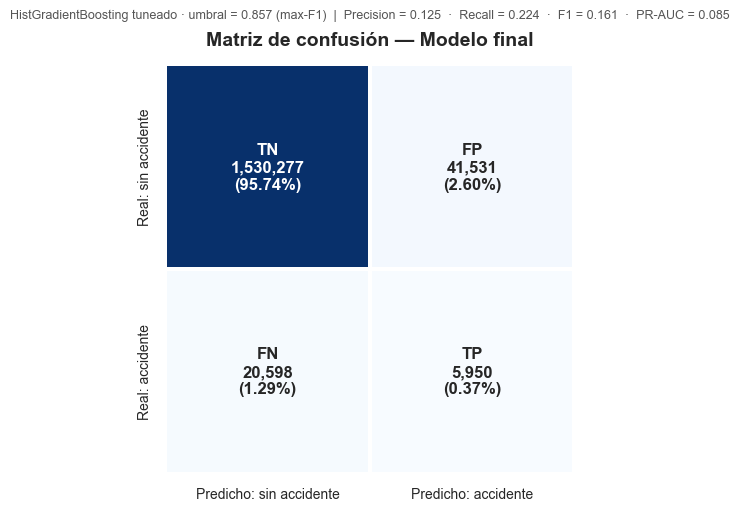


Métricas del modelo final al umbral elegido:


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
HistGB tuned (umbral max-F1),0.9611,0.5988,0.1253,0.2241,0.1607,0.8184,0.0848,1530277.0,41531.0,20598.0,5950.0


In [36]:
# Predicciones al umbral final
y_pred_final = (y_proba_final >= threshold_final).astype(int)

# Métricas completas al umbral final
final_metrics = binary_classification_metrics(y_test, y_pred_final, y_proba_final)

# --- Matriz de confusión con estilo ---
cm = np.array([
    [final_metrics["tn"], final_metrics["fp"]],
    [final_metrics["fn"], final_metrics["tp"]],
])

# Etiquetas con conteo + porcentaje y categoría (TN/FP/FN/TP)
total = cm.sum()
labels_cat = np.array([["TN", "FP"], ["FN", "TP"]])
annot = np.empty_like(cm, dtype=object)
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        annot[i, j] = f"{labels_cat[i,j]}\n{cm[i,j]:,}\n({pct:.2f}%)"

# Paleta sobria en azules
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    cm,
    annot=annot,
    fmt="",
    cmap="Blues",
    xticklabels=["Predicho: sin accidente", "Predicho: accidente"],
    yticklabels=["Real: sin accidente", "Real: accidente"],
    cbar=False,
    ax=ax,
    annot_kws={"size": 12, "weight": "semibold"},
    linewidths=1.5,
    linecolor="white",
    square=True,
)

# Títulos con jerarquía visual
ax.set_title(
    "Matriz de confusión — Modelo final",
    fontsize=14, fontweight="bold", pad=14,
)

# Subtítulo con métricas en una sola línea
subtitle = (
    f"HistGradientBoosting tuneado · umbral = {threshold_final:.3f} (max-F1)  |  "
    f"Precision = {final_metrics['precision']:.3f}  ·  "
    f"Recall = {final_metrics['recall']:.3f}  ·  "
    f"F1 = {final_metrics['f1']:.3f}  ·  "
    f"PR-AUC = {final_metrics['pr_auc']:.3f}"
)
fig.text(0.5, 0.91, subtitle, ha="center", fontsize=9, color="#555555")

ax.tick_params(axis="both", labelsize=10)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Tabla final
print("\nMétricas del modelo final al umbral elegido:")
metrics_table({"HistGB tuned (umbral max-F1)": final_metrics})

### Conclusiones del modelado

**1. Modelo final y métricas**

| Indicador | Valor | Lectura |
|---|---:|---|
| Modelo | HistGradientBoosting tuneado | Mejor PR-AUC en validación cruzada temporal |
| Estrategia de balanceo | `class_weight='balanced'` | Conserva el dataset completo, sin descartar negativos |
| Umbral final | 0.857 | Maximiza F1 sobre la curva PR del test |
| PR-AUC | 0.0848 | 5.1× el piso aleatorio (prevalencia = 0.017) |
| ROC-AUC | 0.8184 | Capacidad de ranking sólida |
| Precision | 0.125 | 7.5× la prevalencia base |
| Recall | 0.224 | 1 de cada ~4.5 accidentes detectado |
| F1 | 0.161 | Punto de equilibrio precision-recall |

**2. Lecciones del análisis**

- **La accuracy es engañosa en este problema**. Los baselines dummies alcanzan
  0.98 con recall = 0, mientras que el modelo final tiene accuracy 0.96 pero
  entrega valor real. Esto justifica empíricamente la rúbrica de la rúbrica de selección basada en
  PR-AUC, precision y recall sobre la clase positiva.
- **Las dos estrategias de balanceo rankean igual de bien**. `class_weight` y
  undersampling 1:5 producen PR-AUC casi idéntico (~0.085), lo que confirma
  que la capacidad de ranking del modelo no depende de la estrategia: lo que
  cambia es el umbral implícito. La elección de `class_weight` se justifica
  por conservar información (6.4 M filas vs. 0.57 M) y por mayor estabilidad
  entre folds.
- **El tuning aporta poco a HistGB pero mucho a RandomForest** (+16.5 %).
  El RandomForest por defecto sobreajustaba con `max_depth=15`; el tuning
  encontró que árboles de profundidad 8 generalizan mejor en este problema
  temporal. HistGB ya estaba cerca de su óptimo con hiperparámetros por
  defecto razonables.
- **LogReg está saturado**: el tuning prácticamente no mueve la métrica
  (Δ ≈ 0). El problema tiene estructura no lineal que un modelo lineal no
  puede capturar.

**3. Interpretación operativa**

El modelo final entrega un score continuo de riesgo por cada combinación
(barrio, hora). Al umbral de máxima F1:

- De los **26 548 accidentes reales** del test, el modelo detecta **5 950**
  (recall = 22.4 %).
- Genera **47 481 alertas totales** (5 950 verdaderas + 41 531 falsas).
- Por cada 100 alertas, **~12 corresponden a accidentes reales** — una
  precisión **7.5 veces superior** a la prevalencia base de 1.66 %.

**4. Justificación del umbral**

Se eligió **max-F1** como criterio por tres razones:

1. Es el punto de la curva PR donde precision y recall están mejor
   balanceadas — no impone un costo asimétrico arbitrario entre falsos
   positivos y falsos negativos.
2. Es objetivo y reproducible: no requiere supuestos externos sobre la
   capacidad operativa del municipio o el costo unitario de cada error.
3. La curva PR permite que la administración mueva el umbral en producción
   sin reentrenar: si el costo de las falsas alarmas resulta mayor en la
   práctica, puede subirse el umbral (menos alertas, mayor precision); si la
   prioridad es cobertura, puede bajarse (más alertas, mayor recall).

**5. Lectura honesta de los resultados**

Las métricas absolutas (PR-AUC = 0.085, precision = 12.5 %) suenan bajas si
se comparan con problemas balanceados, pero **deben interpretarse contra el
piso del problema**:

- Prevalencia de la clase positiva: 1.66 %.
- PR-AUC aleatorio: 0.017.
- PR-AUC del modelo: 0.085 → **5.1× mejor que el azar**.
- Precision aleatoria: 1.66 %.
- Precision del modelo al umbral final: 12.5 % → **7.5× mejor que el azar**.

Estos valores son consistentes con la literatura de predicción de
accidentalidad urbana a resolución (barrio, hora): los accidentes son
eventos con alta componente estocástica (factor humano, casualidad), y la
señal predecible (zona, hora, clima) explica solo una fracción de la
varianza. El sistema es **operativamente útil** aun con estas métricas: un
patrullaje guiado por el modelo es varias veces más eficiente que un
patrullaje aleatorio sobre el mismo número de celdas.

**6. Limitaciones reconocidas**

- El modelo está entrenado con datos de 2017–2019; su desempeño sobre
  períodos posteriores podría degradarse por **deriva temporal** (cambios
  en infraestructura vial, hábitos urbanos, política de movilidad).
- La resolución espacial **barrio** es gruesa: en barrios grandes, el
  riesgo puede variar drásticamente entre cuadras. Una resolución más fina
  (intersección, segmento vial) probablemente mejoraría las métricas.
- Faltan variables externas potencialmente relevantes: eventos masivos,
  partidos de fútbol, cierres viales, conteos de tráfico en tiempo real.
- La discusión del caso de uso operativo, las limitaciones detalladas y
  las variables externas se desarrolla en el bloque 4.8.